In [13]:
#import all libraries in sequence of use
import pandas as pd #same
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from xgboost import XGBRegressor # ref: https://xgboost.readthedocs.io/en/stable/
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv("insurance_pre.csv")

In [3]:
dataset.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges'], dtype='object')

In [4]:
# dataset.replace({"male":1,"female":0, "yes":1,"no":0}, inplace=True)- Prevented in this instant
dataset=pd.get_dummies(dataset,drop_first=True,dtype=int)
# Use get_dummies method simialr to replcae() nut dont overwrite the 

In [5]:
dataset
dataset.head()

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0


In [6]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [7]:
indep=dataset[['age', 'sex_male', 'bmi', 'children', 'smoker_yes']]

In [8]:
indep

,age,sex_male,bmi,children,smoker_yes
0,19,0,27.900,0,1
1,18,1,33.770,1,0
2,28,1,33.000,3,0
3,33,1,22.705,0,0
4,32,1,28.880,0,0
...,...,...,...,...,...
1333,50,1,30.970,3,0
1334,18,0,31.920,0,0
1335,18,0,36.850,0,0
1336,21,0,25.800,0,0


In [9]:
dep=dataset[['charges']]

In [10]:
regressor=XGBRegressor()
# Since K_Fold will do import train_test_split -disabled#
#from sklearn.model_selection import train_test_split 
#X_train,X_test,y_train,y_test=train_test_split(independent, dependent, test_size=0.30,random_state=0)
#-----------K-Fold--------------#
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

scores = cross_val_score(
    estimator=regressor, #!! Regressor assigned
    X=indep, #!! Data X and Y assigned
    y=dep.values.ravel(),#                          
    cv=kfold, #<---------------from kfold=KFold          
    scoring="r2"
)
#-----------K-Fold--------------#
print("="*60)
print("R2 Score for each fold:", scores)
print("Mean R2:", scores.mean())
print("Standard Deviation:", scores.std())
print("="*60)

R2 Score for each fold: [0.88998895 0.78814209 0.82308094 0.85306501 0.7215723  0.72147753
 0.84610561 0.81100236 0.7851779  0.74717995]
Mean R2: 0.7986792636633362
Standard Deviation: 0.0539841782437206


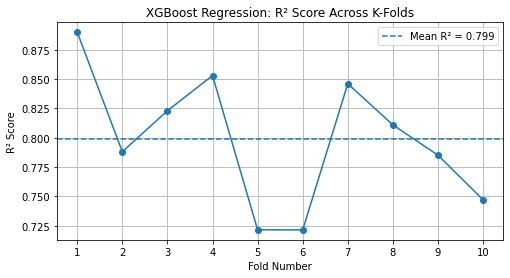

In [11]:
# K-Fold R² performance-shows XGBoost performs consistently across the ten folds
folds = np.arange(1, len(scores) + 1)

plt.figure(figsize=(8, 4))

plt.plot(
    folds,
    scores,
    marker="o"
)

plt.axhline(
    scores.mean(),
    linestyle="--",
    label=f"Mean R² = {scores.mean():.3f}"
)

plt.xlabel("Fold Number")
plt.ylabel("R² Score")
plt.title("XGBoost Regression: R² Score Across K-Folds")
plt.xticks(folds)
plt.grid(True)
plt.legend()
plt.show()

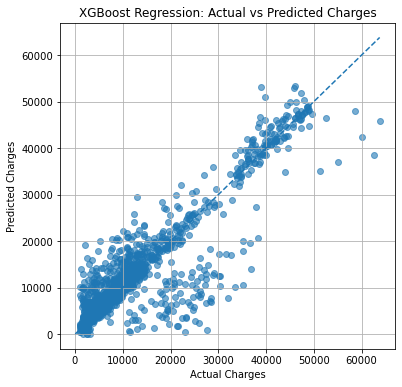

In [14]:
# Actual versus predicted values-Shows Accurate, Over and Under Predicted values
actual = dep.values.ravel()

prediction = cross_val_predict(
    estimator=regressor,
    X=indep,
    y=actual,
    cv=kfold
)

minimum = min(actual.min(), prediction.min())
maximum = max(actual.max(), prediction.max())

plt.figure(figsize=(6, 6))

plt.scatter(
    actual,
    prediction,
    alpha=0.6
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("XGBoost Regression: Actual vs Predicted Charges")
plt.grid(True)
plt.show()

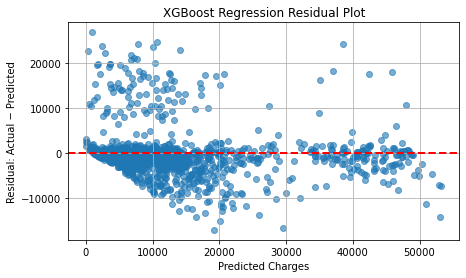

In [16]:
# Residual plot
residual = actual - prediction

plt.figure(figsize=(7, 4))

plt.scatter(
    prediction,
    residual,
    alpha=0.6
)

plt.axhline(
   y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

plt.xlabel("Predicted Charges")
plt.ylabel("Residual: Actual − Predicted")
plt.title("XGBoost Regression Residual Plot")
plt.grid(True)
plt.show()